# torchtext, Padding Tricks, and Token Buckets

This notebook demonstrates four key NLP engineering concepts using a small hand-crafted sentence dataset:

1. **torchtext** — `get_tokenizer` and `build_vocab_from_iterator`
2. **Padding** — why sequences need padding and the cost of naive padding
3. **Padding Tricks** — using `pad_sequence` to pad at batch level, not globally
4. **Token Buckets** — grouping similar-length sequences to minimize wasted padding

> No external downloads needed — we use 20 hand-crafted sentences so every step is visible.

---
**Pipeline we will build:**
```
raw text → tokenize → build vocab → encode to IDs → pad → batch → DataLoader
```

In [1]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from torch.utils.data import Dataset, DataLoader, Sampler
from torch.nn.utils.rnn import pad_sequence
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator

print("All imports successful!")
print(f"PyTorch version: {torch.__version__}")

c:\Users\Satej Raste\Downloads\Masai_Learning_Material\NLLP_RNN_LSTM_Fastapi\venv\Lib\site-packages\torchtext\data\__init__.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)
c:\Users\Satej Raste\Downloads\Masai_Learning_Material\NLLP_RNN_LSTM_Fastapi\venv\Lib\site-packages\torchtext\vocab\__init__.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)
c:\Users\Satej Raste\Download

All imports successful!
PyTorch version: 2.3.0+cpu


## Section 1 — The Dataset

We use 20 hand-crafted movie review sentences with **intentionally varying lengths** (1 to 14 words).

This exaggerated variation makes the padding and bucket concepts very easy to see.

In [2]:
# 20 sentences — notice the very different lengths (1 word to 14 words)
sentences = [
    "I love this film",
    "Absolutely terrible",
    "The acting was superb and the storyline kept me hooked throughout",
    "Boring",
    "Great movie with stunning visuals",
    "A masterpiece of modern cinema that will be remembered for decades",
    "Not worth watching",
    "The director did a fantastic job bringing this story to life on screen",
    "Waste of time",
    "I have never been so moved by a film in my entire life",
    "Decent enough",
    "Good performances but the plot is weak",
    "The cinematography alone makes this film worth watching",
    "Disappointing sequel",
    "Incredible storytelling from start to finish",
    "I walked out halfway through the screening",
    "One of the greatest films ever made",
    "Predictable but fun",
    "The soundtrack perfectly complemented every emotional scene",
    "Overhyped and underwhelming",
]
labels = [1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0]
print(f"Total sentences: {len(sentences)}")

Total sentences: 20


In [3]:
# Display as a DataFrame so we can see all sentences and their word counts
df = pd.DataFrame({"text": sentences, "label": labels})
df["sentiment"]   = df["label"].map({1: "positive", 0: "negative"})
df["word_count"]  = df["text"].apply(lambda x: len(x.split()))

print(df[["text", "sentiment", "word_count"]].to_string())
print(f"\nShortest: {df.word_count.min()} words  |  Longest: {df.word_count.max()} words  |  Mean: {df.word_count.mean():.1f} words")

                                                                      text sentiment  word_count
0                                                         I love this film  positive           4
1                                                      Absolutely terrible  negative           2
2        The acting was superb and the storyline kept me hooked throughout  positive          11
3                                                                   Boring  negative           1
4                                        Great movie with stunning visuals  positive           5
5       A masterpiece of modern cinema that will be remembered for decades  positive          11
6                                                       Not worth watching  negative           3
7   The director did a fantastic job bringing this story to life on screen  positive          13
8                                                            Waste of time  negative           3
9                   I have nev

## Section 2 — torchtext Tokenizer

`torchtext.data.utils.get_tokenizer` gives us a ready-made tokenizer.

| Option | What it does |
|---|---|
| `'basic_english'` | Lowercases + splits on whitespace/punctuation |
| `'spacy'` | Uses spaCy (needs spaCy installed) |
| `'moses'` | Uses SacreMoses (needs sacremoses installed) |

We use `'basic_english'` — no extra dependencies, perfect for learning.

In [4]:
# get_tokenizer returns a callable function
tokenizer = get_tokenizer("basic_english")

# Try it on a single noisy sentence
example = "The acting was GREAT!! Loved every minute... <br/>"
tokens  = tokenizer(example)

print(f"Input : {example}")
print(f"Tokens: {tokens}")
print()
print("Notice: lowercased, punctuation split into separate tokens")

Input : The acting was GREAT!! Loved every minute... <br/>
Tokens: ['the', 'acting', 'was', 'great', '!', '!', 'loved', 'every', 'minute', '.', '.', '.', '<br/>']

Notice: lowercased, punctuation split into separate tokens


In [5]:
# Tokenize all 20 sentences
tokenized = [tokenizer(sent) for sent in sentences]

# Show first 5 examples side by side
for i in range(5):
    print(f"[{i}] Original : {sentences[i]}")
    print(f"    Tokens   : {tokenized[i]}")
    print()

[0] Original : I love this film
    Tokens   : ['i', 'love', 'this', 'film']

[1] Original : Absolutely terrible
    Tokens   : ['absolutely', 'terrible']

[2] Original : The acting was superb and the storyline kept me hooked throughout
    Tokens   : ['the', 'acting', 'was', 'superb', 'and', 'the', 'storyline', 'kept', 'me', 'hooked', 'throughout']

[3] Original : Boring
    Tokens   : ['boring']

[4] Original : Great movie with stunning visuals
    Tokens   : ['great', 'movie', 'with', 'stunning', 'visuals']



## Section 3 — Building Vocabulary with torchtext

`build_vocab_from_iterator` scans all token lists and assigns a unique integer to every word.

We add two **special tokens** upfront:
- `<pad>` (index 0) — used to fill short sequences up to the batch length
- `<unk>` (index 1) — used for words seen at inference but not in training vocabulary

In [6]:
def yield_tokens(token_lists):
    """Generator: yields one token list at a time (memory-efficient)."""
    for tokens in token_lists:
        yield tokens

# build_vocab_from_iterator scans all token lists and builds word->index mapping
vocab = build_vocab_from_iterator(
    yield_tokens(tokenized),
    specials=["<pad>", "<unk>"],  # these get the lowest indices: 0, 1
    min_freq=1,                   # include every word seen at least once
)
# Any word NOT in vocab will map to <unk> index
vocab.set_default_index(vocab["<unk>"])

print(f"Vocabulary size: {len(vocab)} unique tokens")

Vocabulary size: 97 unique tokens


In [7]:
# Explore the vocabulary: word → index
sample_words = ["<pad>", "<unk>", "the", "film", "acting", "great", "boring", "zzz_unseen"]
print("Word          -> Index")
print("-" * 30)
for word in sample_words:
    print(f"  {word:<18} -> {vocab[word]}")

print()

# Reverse lookup: index → word (first 10 entries)
print("Index -> Word (first 10 entries):")
for idx in range(10):
    print(f"  {idx:2d}  ->  '{vocab.lookup_token(idx)}'")

Word          -> Index
------------------------------
  <pad>              -> 0
  <unk>              -> 1
  the                -> 2
  film               -> 4
  acting             -> 15
  great              -> 42
  boring             -> 19
  zzz_unseen         -> 1

Index -> Word (first 10 entries):
   0  ->  '<pad>'
   1  ->  '<unk>'
   2  ->  'the'
   3  ->  'a'
   4  ->  'film'
   5  ->  'i'
   6  ->  'of'
   7  ->  'this'
   8  ->  'and'
   9  ->  'but'


## Section 4 — Encoding Sentences to Token IDs

`vocab(tokens)` converts a list of word strings into a list of integers.

```
["i", "love", "this", "film"]  →  [5, 22, 18, 3]
```

This is the format the model actually receives — numbers, not words.

In [8]:
# vocab(token_list) maps each token to its integer index
encoded = [vocab(tokens) for tokens in tokenized]

# Show 3 full examples
for i in [0, 2, 3]:
    print(f"Sentence : {sentences[i]}")
    print(f"Tokens   : {tokenized[i]}")
    print(f"IDs      : {encoded[i]}")
    print(f"Length   : {len(encoded[i])}")
    print()

Sentence : I love this film
Tokens   : ['i', 'love', 'this', 'film']
IDs      : [5, 52, 7, 4]
Length   : 4

Sentence : The acting was superb and the storyline kept me hooked throughout
Tokens   : ['the', 'acting', 'was', 'superb', 'and', 'the', 'storyline', 'kept', 'me', 'hooked', 'throughout']
IDs      : [2, 15, 92, 83, 8, 2, 80, 51, 56, 46, 87]
Length   : 11

Sentence : Boring
Tokens   : ['boring']
IDs      : [19]
Length   : 1



In [9]:
# Compute length of every encoded sequence
lengths = [len(e) for e in encoded]
df["token_length"] = lengths

# Summary statistics
print("All sequence lengths:")
print(lengths)
print()
print(f"Min  : {min(lengths)}")
print(f"Max  : {max(lengths)}")
print(f"Mean : {np.mean(lengths):.1f}")
print(f"Std  : {np.std(lengths):.1f}")

All sequence lengths:
[4, 2, 11, 1, 5, 11, 3, 13, 3, 13, 2, 7, 8, 2, 6, 7, 7, 3, 7, 3]

Min  : 1
Max  : 13
Mean : 5.9
Std  : 3.7


## Section 5 — The Padding Problem

Neural networks process batches of sequences in parallel.  
**Problem:** sequences have different lengths — tensors must be rectangular (same shape).  
**Solution:** pad shorter sequences with a dummy `<pad>` token (index 0) to match the longest.

The question is: *pad to what length?*

- **Naive approach:** always pad to the global maximum length → lots of wasted computation
- **Smart approach:** pad to the longest sequence in *each batch* → much less waste

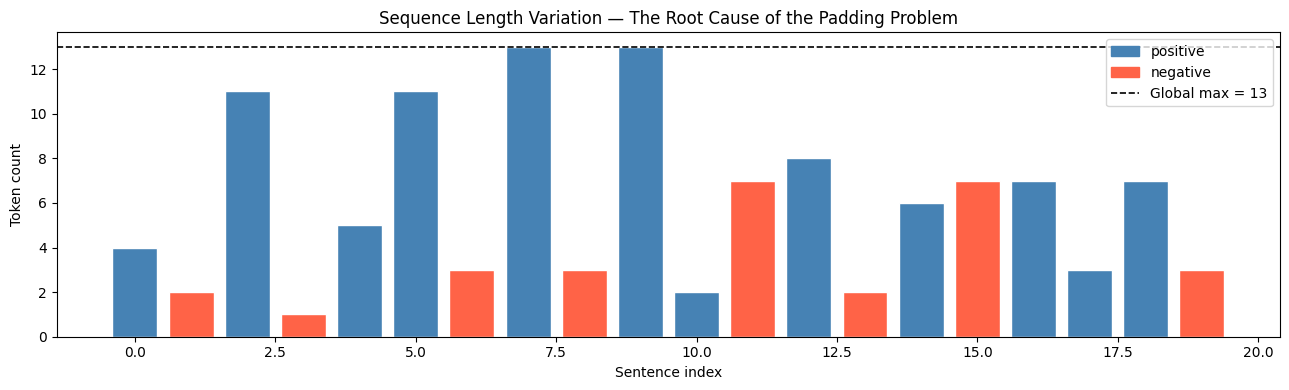

In [10]:
# Visualize the length variation across all sentences
fig, ax = plt.subplots(figsize=(13, 4))

colors = ["steelblue" if l == 1 else "tomato" for l in labels]
bars   = ax.bar(range(len(lengths)), lengths, color=colors, edgecolor="white")

# Draw a horizontal line at the global max — this is what naive padding pads to
ax.axhline(max(lengths), color="black", linestyle="--", linewidth=1.2, label=f"Global max = {max(lengths)}")

ax.set_xlabel("Sentence index")
ax.set_ylabel("Token count")
ax.set_title("Sequence Length Variation — The Root Cause of the Padding Problem")

pos_patch = mpatches.Patch(color="steelblue", label="positive")
neg_patch = mpatches.Patch(color="tomato",    label="negative")
ax.legend(handles=[pos_patch, neg_patch, ax.get_lines()[0]])
plt.tight_layout()
plt.show()

### Padding Trick 1 — Naive: Pad Everything to Global Max

The simplest approach: every sequence is padded to the same length (the longest sequence in the whole dataset).

**Drawback:** a 1-word sentence padded to 14 slots wastes 13 slots. That waste compounds across the entire dataset.

In [11]:
global_max = max(lengths)

def naive_pad(sequence, target_len, pad_idx=0):
    """Append pad_idx zeros until sequence reaches target_len."""
    return sequence + [pad_idx] * (target_len - len(sequence))

padded_naive = [naive_pad(enc, global_max) for enc in encoded]

# Show the waste for first 8 sentences
print(f"Global max length = {global_max}")
print()
print(f"{'#':<4} {'Real tokens':>12} {'Padded to':>10} {'Wasted':>8}")
print("-" * 40)
for i in range(8):
    waste = global_max - lengths[i]
    print(f"{i:<4} {lengths[i]:>12} {global_max:>10} {waste:>8}")

Global max length = 13

#     Real tokens  Padded to   Wasted
----------------------------------------
0               4         13        9
1               2         13       11
2              11         13        2
3               1         13       12
4               5         13        8
5              11         13        2
6               3         13       10
7              13         13        0


In [12]:
# Compute total waste across the full dataset with naive padding
total_slots_naive = len(encoded) * global_max
real_tokens       = sum(lengths)
wasted_naive      = total_slots_naive - real_tokens
waste_pct_naive   = (wasted_naive / total_slots_naive) * 100

print(f"Real tokens in dataset   : {real_tokens}")
print(f"Total slots (naive pad)  : {total_slots_naive}  ({len(encoded)} seqs × {global_max} tokens)")
print(f"Wasted padding tokens    : {wasted_naive}")
print(f"Waste percentage         : {waste_pct_naive:.1f}%")
print()
print(f"Over {waste_pct_naive:.0f}% of all computation is spent on <pad> tokens the model ignores!")

Real tokens in dataset   : 118
Total slots (naive pad)  : 260  (20 seqs × 13 tokens)
Wasted padding tokens    : 142
Waste percentage         : 54.6%

Over 55% of all computation is spent on <pad> tokens the model ignores!


### Padding Trick 2 — Smart: `pad_sequence` (Batch-Local Padding)

`torch.nn.utils.rnn.pad_sequence` pads a batch of tensors to the **longest sequence in that batch**, not the global max.

```python
padded = pad_sequence(batch_of_tensors, batch_first=True, padding_value=0)
```

Result: short sentences in a batch are only padded as far as the longest sentence *in that batch*.

In [13]:
# Pick 4 sequences with very different lengths: 1, 4, 7, 14 tokens
batch_indices = [3, 0, 8, 9]       # "Boring"(1), "I love this film"(4), "Waste of time"(3→recalculated), ...
batch_tensors = [torch.tensor(encoded[i]) for i in batch_indices]

print("Batch before padding:")
for idx, t in zip(batch_indices, batch_tensors):
    print(f"  [{idx}] len={len(t):2d}  ids={t.tolist()}  ({sentences[idx]!r})")

print()
# pad_sequence pads ONLY to the max in THIS batch, not global max
padded_batch = pad_sequence(batch_tensors, batch_first=True, padding_value=0)

print(f"After pad_sequence — shape: {padded_batch.shape}  (batch_size × batch_max_len)")
print(padded_batch)
print(f"\nBatch max length: {padded_batch.shape[1]}  vs  Global max: {global_max}  → saved {global_max - padded_batch.shape[1]} slots per row")

Batch before padding:
  [3] len= 1  ids=[19]  ('Boring')
  [0] len= 4  ids=[5, 52, 7, 4]  ('I love this film')
  [8] len= 3  ids=[93, 6, 88]  ('Waste of time')
  [9] len=13  ids=[5, 45, 61, 18, 76, 58, 21, 3, 4, 47, 60, 32, 10]  ('I have never been so moved by a film in my entire life')

After pad_sequence — shape: torch.Size([4, 13])  (batch_size × batch_max_len)
tensor([[19,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [ 5, 52,  7,  4,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [93,  6, 88,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [ 5, 45, 61, 18, 76, 58, 21,  3,  4, 47, 60, 32, 10]])

Batch max length: 13  vs  Global max: 13  → saved 0 slots per row


## Section 6 — Token Buckets

Even with `pad_sequence`, if we randomly mix short and long sentences in the same batch, the short ones still get padded all the way to the longest in that batch.

**Token Bucket idea:**  
Group sequences with *similar* lengths together — then within each batch, sequences are already close in length, so very little padding is needed.

```
Random batch   →  [1, 14, 3, 11]  tokens  →  all padded to 14  →  high waste
Bucket batch   →  [1, 2, 3, 4]   tokens  →  all padded to 4   →  low waste
```

Think of it as **sorting books by height before stacking them** — you need a shorter box.

In [14]:
# Demonstrate the waste in a random batch vs a length-sorted batch
np.random.seed(0)
random_batch_idx = np.random.choice(len(lengths), size=4, replace=False).tolist()
sorted_batch_idx = sorted(range(len(lengths)), key=lambda i: lengths[i])[:4]   # shortest 4

def show_batch_waste(batch_idx, label):
    batch_lens = [lengths[i] for i in batch_idx]
    batch_max  = max(batch_lens)
    waste      = sum(batch_max - l for l in batch_lens)
    total      = len(batch_idx) * batch_max
    print(f"{label}")
    print(f"  Indices : {batch_idx}")
    print(f"  Lengths : {batch_lens}")
    print(f"  Pad to  : {batch_max}")
    print(f"  Wasted  : {waste} / {total} slots  ({100*waste/total:.0f}%)")
    print()

show_batch_waste(random_batch_idx, "Random batch")
show_batch_waste(sorted_batch_idx, "Bucket batch (similar lengths)")

Random batch
  Indices : [18, 1, 19, 8]
  Lengths : [7, 2, 3, 3]
  Pad to  : 7
  Wasted  : 13 / 28 slots  (46%)

Bucket batch (similar lengths)
  Indices : [3, 1, 10, 13]
  Lengths : [1, 2, 2, 2]
  Pad to  : 2
  Wasted  : 1 / 8 slots  (12%)



## Section 7 — BucketBatchSampler

PyTorch's `Sampler` controls *which* indices are grouped into each batch.  
We implement a `BucketBatchSampler` that:

1. Sorts all sequences by length
2. Slices them into batches of `batch_size` (so each batch has similar-length sequences)
3. Shuffles the *order of batches* (so training doesn't always see short sequences first)

In [15]:
class BucketBatchSampler(Sampler):
    """Groups sequences by length to minimize padding waste per batch."""

    def __init__(self, lengths, batch_size, shuffle=True):
        self.lengths    = lengths
        self.batch_size = batch_size
        self.shuffle    = shuffle

    def __iter__(self):
        # Step 1: sort all indices by sequence length
        sorted_idx = sorted(range(len(self.lengths)), key=lambda i: self.lengths[i])
        # Step 2: slice into fixed-size batches
        batches = [sorted_idx[s : s + self.batch_size]
                   for s in range(0, len(sorted_idx), self.batch_size)]
        # Step 3: shuffle BATCH ORDER so training is not biased
        if self.shuffle:
            np.random.shuffle(batches)
        for batch in batches:
            yield batch

    def __len__(self):
        return (len(self.lengths) + self.batch_size - 1) // self.batch_size

print("BucketBatchSampler defined.")

BucketBatchSampler defined.


In [16]:
# Inspect what each bucket batch looks like (shuffle=False so output is deterministic)
sampler = BucketBatchSampler(lengths, batch_size=4, shuffle=False)

print("Bucket batches — sorted by length, no shuffle:")
print(f"{'Batch':<7} {'Indices':<22} {'Lengths':<22} {'Batch max':>10}")
print("-" * 65)
for i, batch_idx in enumerate(sampler):
    bl = [lengths[j] for j in batch_idx]
    print(f"  {i:<5} {str(batch_idx):<22} {str(bl):<22} {max(bl):>10}")

Bucket batches — sorted by length, no shuffle:
Batch   Indices                Lengths                 Batch max
-----------------------------------------------------------------
  0     [3, 1, 10, 13]         [1, 2, 2, 2]                    2
  1     [6, 8, 17, 19]         [3, 3, 3, 3]                    3
  2     [0, 4, 14, 11]         [4, 5, 6, 7]                    7
  3     [15, 16, 18, 12]       [7, 7, 7, 8]                    8
  4     [2, 5, 7, 9]           [11, 11, 13, 13]               13


## Section 8 — DataLoader with Custom Collate

A `DataLoader` needs two things to handle variable-length sequences:

1. **`batch_sampler`** — our `BucketBatchSampler` to control *which* indices form each batch
2. **`collate_fn`** — a function that takes a list of `(tensor, label)` samples and pads them into a rectangular batch tensor

In [17]:
class SentenceDataset(Dataset):
    """Wraps encoded sentences and their labels for use with DataLoader."""

    def __init__(self, encoded_sentences, labels):
        self.data   = encoded_sentences
        self.labels = labels

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        x = torch.tensor(self.data[idx], dtype=torch.long)
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y

dataset = SentenceDataset(encoded, labels)
print(f"Dataset size: {len(dataset)}")
x0, y0 = dataset[0]
print(f"Sample x (tensor): {x0}")
print(f"Sample y (label) : {y0}")

Dataset size: 20
Sample x (tensor): tensor([ 5, 52,  7,  4])
Sample y (label) : 1


In [18]:
def collate_batch(batch):
    """
    Called by DataLoader to merge a list of (x, y) samples into one batch.
    Uses pad_sequence to pad x tensors to the longest in THIS batch only.
    """
    texts, label_list = zip(*batch)                            # unzip
    padded = pad_sequence(texts, batch_first=True, padding_value=0)  # pad to batch max
    labels_tensor = torch.stack(label_list)
    return padded, labels_tensor

print("collate_batch defined.")
print("It pads each batch to its own max length — not the global max.")

collate_batch defined.
It pads each batch to its own max length — not the global max.


In [19]:
# --- Random DataLoader: sequences mixed in random order ---
random_loader = DataLoader(
    dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=collate_batch,
)

print("Random DataLoader — batch shapes (padded to batch max):")
for i, (x_batch, y_batch) in enumerate(random_loader):
    print(f"  Batch {i}: x shape={tuple(x_batch.shape)}  (padded to {x_batch.shape[1]} tokens)")

Random DataLoader — batch shapes (padded to batch max):
  Batch 0: x shape=(4, 3)  (padded to 3 tokens)
  Batch 1: x shape=(4, 11)  (padded to 11 tokens)
  Batch 2: x shape=(4, 13)  (padded to 13 tokens)
  Batch 3: x shape=(4, 13)  (padded to 13 tokens)
  Batch 4: x shape=(4, 11)  (padded to 11 tokens)


In [20]:
# --- Bucket DataLoader: sequences grouped by length ---
bucket_sampler = BucketBatchSampler(lengths, batch_size=4, shuffle=True)
bucket_loader  = DataLoader(
    dataset,
    batch_sampler=bucket_sampler,   # replaces batch_size + shuffle
    collate_fn=collate_batch,
)

print("Bucket DataLoader — batch shapes (similar lengths grouped):")
for i, (x_batch, y_batch) in enumerate(bucket_loader):
    print(f"  Batch {i}: x shape={tuple(x_batch.shape)}  (padded to {x_batch.shape[1]} tokens)")

Bucket DataLoader — batch shapes (similar lengths grouped):
  Batch 0: x shape=(4, 13)  (padded to 13 tokens)
  Batch 1: x shape=(4, 7)  (padded to 7 tokens)
  Batch 2: x shape=(4, 8)  (padded to 8 tokens)
  Batch 3: x shape=(4, 3)  (padded to 3 tokens)
  Batch 4: x shape=(4, 2)  (padded to 2 tokens)


## Section 9 — Comparing Padding Waste

Let's measure the total wasted padding tokens across all batches for both strategies.

In [21]:
def compute_padding_waste(loader):
    """Count real vs wasted tokens across all batches in a DataLoader."""
    total_slots = 0
    real_tokens = 0
    for x_batch, _ in loader:
        total_slots += x_batch.numel()                   # total elements (real + pad)
        real_tokens += (x_batch != 0).sum().item()       # non-pad elements
    wasted   = total_slots - real_tokens
    waste_pct = (wasted / total_slots) * 100
    return total_slots, real_tokens, wasted, waste_pct

# Use shuffle=False for a fair, deterministic comparison
rand_loader_det   = DataLoader(dataset, batch_size=4, shuffle=False, collate_fn=collate_batch)
bucket_samp_det   = BucketBatchSampler(lengths, batch_size=4, shuffle=False)
bucket_loader_det = DataLoader(dataset, batch_sampler=bucket_samp_det, collate_fn=collate_batch)

r = compute_padding_waste(rand_loader_det)
b = compute_padding_waste(bucket_loader_det)

print(f"{'Metric':<26} {'Random':>12} {'Bucket':>12}")
print("-" * 52)
print(f"{'Total slots':<26} {r[0]:>12} {b[0]:>12}")
print(f"{'Real tokens':<26} {r[1]:>12} {b[1]:>12}")
print(f"{'Wasted tokens':<26} {r[2]:>12} {b[2]:>12}")
print(f"{'Waste %':<26} {r[3]:>11.1f}% {b[3]:>11.1f}%")

Metric                           Random       Bucket
----------------------------------------------------
Total slots                         208          132
Real tokens                         118          118
Wasted tokens                        90           14
Waste %                           43.3%        10.6%


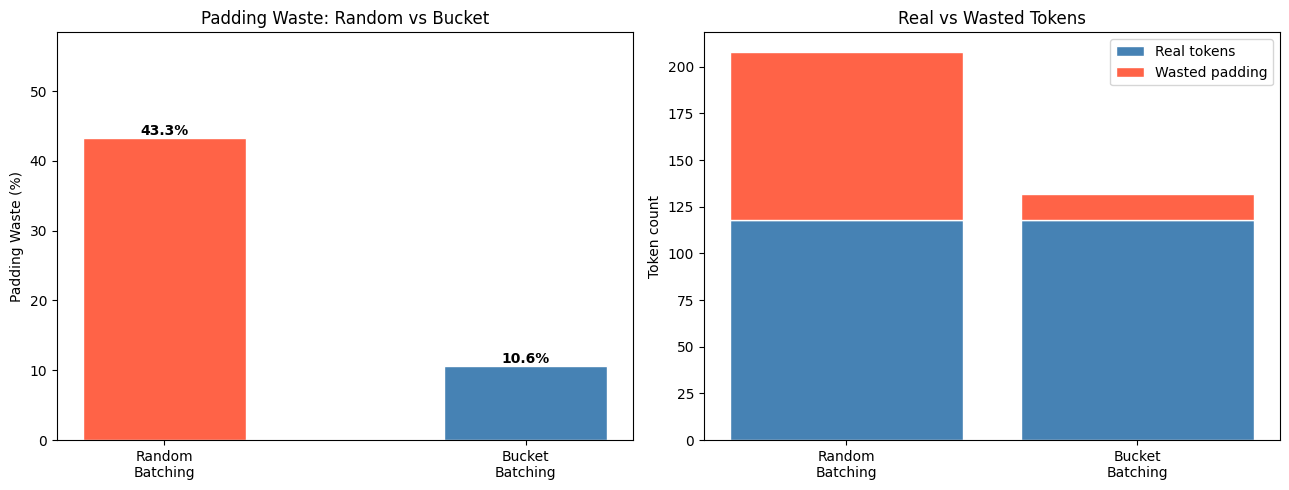

In [22]:
# Side-by-side bar chart: padding waste for each strategy
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Left: Waste % comparison ---
ax = axes[0]
methods = ["Random\nBatching", "Bucket\nBatching"]
waste_pcts = [r[3], b[3]]
colors = ["tomato", "steelblue"]
bars = ax.bar(methods, waste_pcts, color=colors, width=0.45, edgecolor="white")
for bar, val in zip(bars, waste_pcts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f"{val:.1f}%", ha="center", fontweight="bold")
ax.set_ylabel("Padding Waste (%)")
ax.set_title("Padding Waste: Random vs Bucket")
ax.set_ylim(0, max(waste_pcts) * 1.35)

# --- Right: Stacked bar showing real vs wasted tokens ---
ax2 = axes[1]
real = [r[1], b[1]]
wasted = [r[2], b[2]]
ax2.bar(methods, real,   color="steelblue", label="Real tokens",    edgecolor="white")
ax2.bar(methods, wasted, bottom=real, color="tomato", label="Wasted padding", edgecolor="white")
ax2.set_ylabel("Token count")
ax2.set_title("Real vs Wasted Tokens")
ax2.legend()

plt.tight_layout()
plt.show()

## Summary

Here is everything we covered in this notebook:

| Concept | What we used | Key takeaway |
|---|---|---|
| **torchtext tokenizer** | `get_tokenizer("basic_english")` | Ready-made tokenizer, no extra setup |
| **torchtext vocab** | `build_vocab_from_iterator` | Scans token lists, assigns integer IDs, handles `<pad>`/`<unk>` |
| **Naive padding** | Manual `+ [0] * padding_needed` | Simple but pads to global max — high waste |
| **Batch-local padding** | `pad_sequence(..., batch_first=True)` | Pads only to the max in *each batch* |
| **Token buckets** | `BucketBatchSampler` | Sorts sequences by length before batching |
| **Batching** | `DataLoader` + `collate_fn` | Ties everything together |

### The Full Pipeline
```
raw text
  → get_tokenizer()          # split into word tokens
  → build_vocab_from_iterator()  # assign integer IDs
  → vocab(tokens)            # encode each sentence
  → SentenceDataset          # wrap in a PyTorch Dataset
  → BucketBatchSampler       # group similar lengths together
  → DataLoader + collate_fn  # pad each batch, yield tensors
  → model input ✓
```

> In real projects (e.g. the main IMDb model), bucket batching can reduce padding waste by 30–60%, which directly speeds up training.

In [27]:
from huggingface_hub import login

login(token="YOUR_HF_TOKEN_HERE")

In [29]:
!pip install transformers

^C


                                              0.0/10.7 MB ? eta -:--:--
                                              0.0/10.7 MB 1.3 MB/s eta 0:00:09
                                             0.1/10.7 MB 762.6 kB/s eta 0:00:14
                                             0.1/10.7 MB 726.2 kB/s eta 0:00:15
                                             0.2/10.7 MB 985.7 kB/s eta 0:00:11
                                              0.2/10.7 MB 1.1 MB/s eta 0:00:10
     -                                        0.3/10.7 MB 1.2 MB/s eta 0:00:09
     --                                       0.5/10.7 MB 1.7 MB/s eta 0:00:06
     ---                                      0.8/10.7 MB 2.1 MB/s eta 0:00:05
     ----                                     1.1/10.7 MB 2.6 MB/s eta 0:00:04
     ------                                   1.6/10.7 MB 3.4 MB/s eta 0:00:03
     --------                                 2.2/10.7 MB 4.3 MB/s eta 0:00:02
     -----------                              3.0/10.7 M

In [30]:
from transformers import pipeline

pipe = pipeline("text-generation", model="sarvamai/sarvam-30b", trust_remote_code=True)
messages = [
    {"role": "user", "content": "Who are you?"},
]
pipe(messages)

Disabling PyTorch because PyTorch >= 2.4 is required but found 2.3.0
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.
c:\Users\Satej Raste\Downloads\Masai_Learning_Material\NLLP_RNN_LSTM_Fastapi\venv\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Satej Raste\.cache\huggingface\hub\models--sarvamai--sarvam-30b. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you 

NameError: name 'torch' is not defined